# 01 — Amplification and Near-Peg Slippage Surface

This notebook studies how the StableSwap amplification coefficient `A` changes near-peg slippage.

The goal is not to build a production pricing engine. The goal is to visualize one core StableSwap intuition:

> Higher `A` makes the pool behave more like constant-sum near balance, reducing slippage for small trades.

Security relevance:

- `A` controls how much low-slippage trading the pool offers near balance.
- A higher `A` can improve stable-asset trading efficiency.
- But it also changes the pool's stress surface: prices may remain flat for longer before moving sharply under imbalance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from curve_stableswap_lab.scenarios import amp_slippage_grid
from curve_stableswap_lab.stableswap_math import A_PRECISION, PRECISION

In [7]:
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
amps = [
    20 * A_PRECISION,
    50 * A_PRECISION,
    100 * A_PRECISION,
    500 * A_PRECISION,
]

pool_balance = 10**18

trade_sizes = [
    pool_balance // 10_000,  # 0.01%
    pool_balance // 5_000,   # 0.02%
    pool_balance // 2_000,   # 0.05%
    pool_balance // 1_000,   # 0.10%
    pool_balance // 500,     # 0.20%
    pool_balance // 200,     # 0.50%
    pool_balance // 100,     # 1.00%
    pool_balance // 50,      # 2.00%
    pool_balance // 20,      # 5.00%
    pool_balance // 10,      # 10.00%
]

In [9]:
df = amp_slippage_grid(
    amps=amps,
    trade_sizes=trade_sizes,
    pool_balance=pool_balance,
    n_coins=2,
    i=0,
    j=1,
    fee=0,
)

df.head()

,amp,A,trade_size,trade_size_pct,dy,dy_over_dx,slippage,slippage_bps,fee
0,2000,20.0,100000000000000,0.0001,99999523811787,0.999995,0.000005,0.047619,0
1,2000,20.0,200000000000000,0.0002,199998095256166,0.999990,0.000010,0.095237,0
2,2000,20.0,500000000000000,0.0005,499988095518835,0.999976,0.000024,0.238090,0
3,2000,20.0,1000000000000000,0.0010,999952383176660,0.999952,0.000048,0.476168,0
4,2000,20.0,2000000000000000,0.0020,1999809541257510,0.999905,0.000095,0.952294,0


In [10]:
plot_df = df.copy()

plot_df["trade_size_pct_display"] = plot_df["trade_size_pct"] * 100
plot_df["slippage_bps_display"] = plot_df["slippage_bps"]
plot_df["A_label"] = plot_df["A"].map(lambda x: f"A={x:g}")

plot_df[
    [
        "A",
        "trade_size_pct_display",
        "dy_over_dx",
        "slippage_bps_display",
    ]
].head(10)

,A,trade_size_pct_display,dy_over_dx,slippage_bps_display
0,20.0,0.01,0.999995,0.047619
1,20.0,0.02,0.999990,0.095237
2,20.0,0.05,0.999976,0.238090
3,20.0,0.10,0.999952,0.476168
4,20.0,0.20,0.999905,0.952294
5,20.0,0.50,0.999762,2.380440
6,20.0,1.00,0.999524,4.760070
7,20.0,2.00,0.999048,9.518195
8,20.0,5.00,0.997619,23.806690
9,20.0,10.00,0.995218,47.822816


In [11]:
table_path = TABLE_DIR / "amp_slippage_surface.csv"
plot_df.to_csv(table_path, index=False)

table_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/tables/amp_slippage_surface.csv')

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/amp_slippage_surface.png')

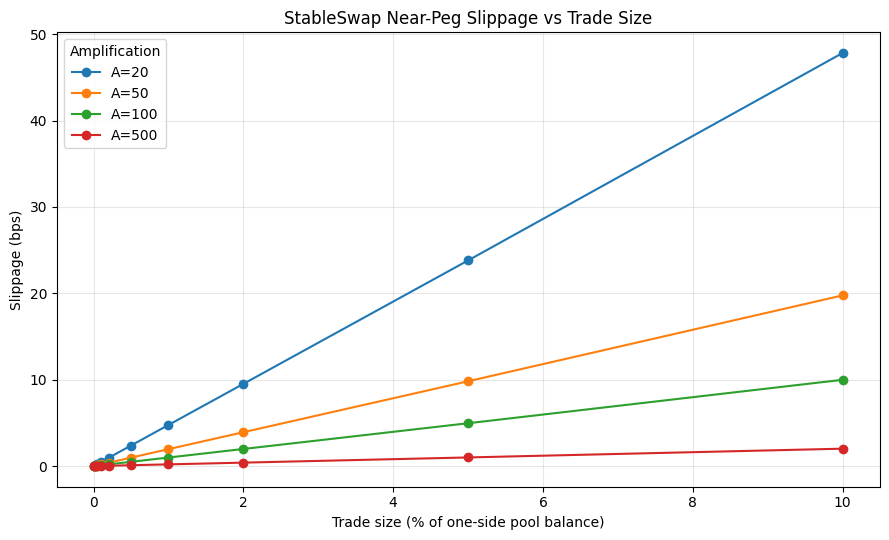

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for A, group in plot_df.groupby("A"):
    group = group.sort_values("trade_size_pct_display")
    ax.plot(
        group["trade_size_pct_display"],
        group["slippage_bps_display"],
        marker="o",
        label=f"A={A:g}",
    )

ax.set_title("StableSwap Near-Peg Slippage vs Trade Size")
ax.set_xlabel("Trade size (% of one-side pool balance)")
ax.set_ylabel("Slippage (bps)")
ax.legend(title="Amplification")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "amp_slippage_surface.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/amp_output_efficiency.png')

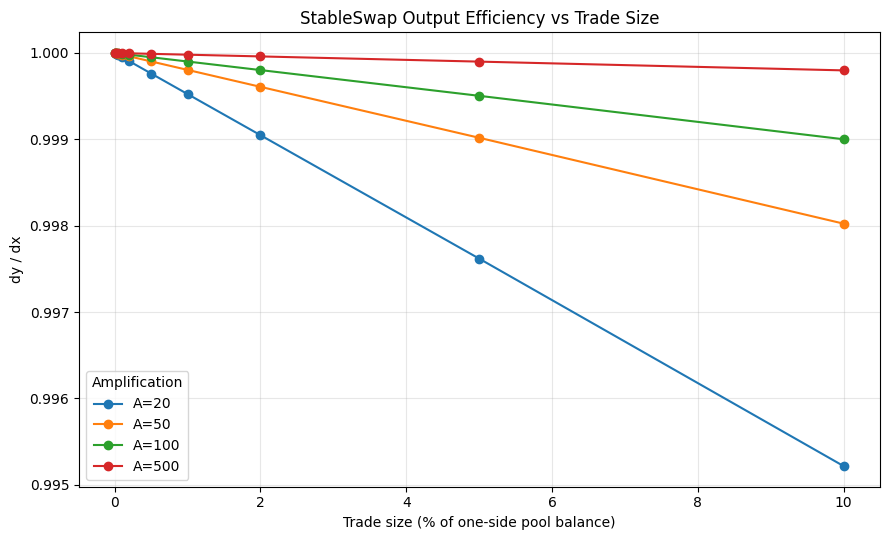

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for A, group in plot_df.groupby("A"):
    group = group.sort_values("trade_size_pct_display")
    ax.plot(
        group["trade_size_pct_display"],
        group["dy_over_dx"],
        marker="o",
        label=f"A={A:g}",
    )

ax.set_title("StableSwap Output Efficiency vs Trade Size")
ax.set_xlabel("Trade size (% of one-side pool balance)")
ax.set_ylabel("dy / dx")
ax.legend(title="Amplification")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "amp_output_efficiency.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

In [15]:
summary = (
    plot_df
    .groupby("A")
    .agg(
        min_slippage_bps=("slippage_bps_display", "min"),
        max_slippage_bps=("slippage_bps_display", "max"),
        mean_slippage_bps=("slippage_bps_display", "mean"),
        min_dy_over_dx=("dy_over_dx", "min"),
        max_dy_over_dx=("dy_over_dx", "max"),
    )
    .reset_index()
)

summary

,A,min_slippage_bps,max_slippage_bps,mean_slippage_bps,min_dy_over_dx,max_dy_over_dx
0,20.0,0.047619,47.822816,9.009762,0.995218,0.999995
1,50.0,0.019608,19.758602,3.718399,0.998024,0.999998
2,100.0,0.009901,9.988914,1.879105,0.999001,0.999999
3,500.0,0.001996,2.015678,0.379068,0.999798,1.000000


## Takeaways

The simulation confirms the expected StableSwap behavior:

1. Higher `A` reduces near-peg slippage.
2. For small trades, high-`A` pools behave more like constant-sum pools.
3. As trade size grows, slippage increases for all `A` values.
4. The effect of `A` is most visible when the pool starts near balance.

Security interpretation:

`A` is not just a pricing parameter. It shapes the pool's stress surface.

A higher `A` can make a stable pool more efficient near peg, but it can also delay visible price movement as the pool becomes imbalanced. For auditors and integrators, this means that slippage, oracle reads, and stress scenarios should be tested across multiple `A` values rather than assuming one generic StableSwap curve.